India Data Analyst Job Market Analysis

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')

df= pd.read_csv('../data/naukri_jobs_with_skills.csv')
print(f"Total jobs loaded: {len(df)}")
df.head(3)

Total jobs loaded: 397


,job_id,Title,Company,Experience,Location,Description,Posted_Date,Skills_Listed,Job_URL,date_scraped,...,GenAI,Deep Learning,NLP,Data Visualization,Hadoop,Airflow,Docker,BigQuery,SAS,total_skills_found
0,21225014173,Data Analyst,Capgemini,4-9 Yrs,"Hybrid - Chennai, Delhi / NCR, Mumbai (All Areas)",Required Skills & Qualifications: . Bachelors ...,3+ weeks ago,"Power Bi, Data Analysis, Data Visualization, T...",https://www.naukri.com/job-listings-data-analy...,2026-06-22,...,0,0,0,1,0,0,0,0,0,5
1,221025507695,Data Analyst,Snapdeal,1-6 Yrs,Gurugram,Providing technical expertise in data storage ...,3+ weeks ago,"master data, python, metadata, data analysis, ...",https://www.naukri.com/job-listings-data-analy...,2026-06-22,...,0,0,0,0,0,0,0,0,0,1
2,200326006395,Data Analyst,Kiya.ai,3-7 Yrs,"Hybrid - Bengaluru, Mumbai (All Areas)",Must possess the ability to research and resol...,4 days ago,"Power Bi, Data Analysis, Tableau, SQL, Capital...",https://www.naukri.com/job-listings-data-analy...,2026-06-22,...,0,0,0,0,0,0,0,0,0,3


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 41 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   job_id              397 non-null    int64
 1   Title               397 non-null    str  
 2   Company             397 non-null    str  
 3   Experience          389 non-null    str  
 4   Location            397 non-null    str  
 5   Description         390 non-null    str  
 6   Posted_Date         397 non-null    str  
 7   Skills_Listed       390 non-null    str  
 8   Job_URL             397 non-null    str  
 9   date_scraped        397 non-null    str  
 10  SQL                 397 non-null    int64
 11  Python              397 non-null    int64
 12  Excel               397 non-null    int64
 13  Power BI            397 non-null    int64
 14  Tableau             397 non-null    int64
 15  AWS                 397 non-null    int64
 16  Azure               397 non-null    int64
 17  GCP     

Data Cleaning 

In [3]:
print(df[['Title', 'Company', 'Location', 'Experience']].isna().sum())
# Drop rows where Title or Company is missing — these are unusable
df = df.dropna(subset=['Title', 'Company'])
print(f"Jobs after dropping missing Title/Company: {len(df)}")

Title         0
Company       0
Location      0
Experience    8
dtype: int64
Jobs after dropping missing Title/Company: 397


In [4]:
# Cleaning experience column to extract min experience in years


import re

def extract_min_experience(exp_text):
    if pd.isna(exp_text) or exp_text == 'N/A':
        return np.nan
    match = re.search(r'(\d+)', str(exp_text))
    if match:
        return int(match.group(1))
    return np.nan

df['min_experience'] = df['Experience'].apply(extract_min_experience)
df[['Experience', 'min_experience']].head(10)


# Create experience level buckets
def experience_bucket(years):
    if pd.isna(years):
        return 'Unknown'
    elif years == 0:
        return 'Fresher (0 yrs)'
    elif years <= 2:
        return 'Junior (0-2 yrs)'
    elif years <= 5:
        return 'Mid (3-5 yrs)'
    else:
        return 'Senior (5+ yrs)'

df['experience_level'] = df['min_experience'].apply(experience_bucket)
df['experience_level'].value_counts()



experience_level
Junior (0-2 yrs)    142
Mid (3-5 yrs)       134
Fresher (0 yrs)      78
Senior (5+ yrs)      35
Unknown               8
Name: count, dtype: int64

In [5]:
# Clean Posted_Date into recency buckets
def clean_posted_date(date_text):
    date_text = str(date_text).lower()
    if 'today' in date_text or 'few hours' in date_text:
        return 'Today'
    elif 'day' in date_text:
        return 'This Week'
    elif '1 week' in date_text:
        return '1-2 Weeks'
    elif '2 week' in date_text:
        return '2-3 Weeks'
    elif '3+' in date_text or '3 week' in date_text:
        return '3+ Weeks'
    else:
        return 'Unknown'

df['recency_bucket'] = df['Posted_Date'].apply(clean_posted_date)
df['recency_bucket'].value_counts()

recency_bucket
3+ Weeks     182
This Week     70
1-2 Weeks     61
Today         39
2-3 Weeks     37
Unknown        8
Name: count, dtype: int64

In [6]:
# Clean Location — split multi-location postings, take primary location
def clean_location(loc_text):
    if pd.isna(loc_text):
        return 'Unknown'
    loc_text = str(loc_text).replace('Hybrid - ', '').strip()
    primary = loc_text.split(',')[0].strip()
    return primary

df['primary_location'] = df['Location'].apply(clean_location)
df['primary_location'].value_counts().head(15)

primary_location
Bengaluru             83
Hyderabad             58
Pune                  39
Gurugram              28
Chennai               25
Mumbai                21
Remote                16
Noida                 16
New Delhi             16
Mumbai (All Areas)    10
Kolkata                8
Pimpri-Chinchwad       3
Jaipur                 3
Coimbatore             3
Navi Mumbai            3
Name: count, dtype: int64

In [7]:
# Consolidate location variants
location_map = {
    'Mumbai (All Areas)': 'Mumbai',
    'Navi Mumbai': 'Mumbai',
    'Pimpri-Chinchwad': 'Pune',
    'Noida': 'Delhi NCR',
    'New Delhi': 'Delhi NCR',
    'Gurugram': 'Delhi NCR',
    'Delhi': 'Delhi NCR',
}

df['primary_location'] = df['primary_location'].replace(location_map)
df['primary_location'].value_counts().head(10)

primary_location
Bengaluru     83
Delhi NCR     60
Hyderabad     58
Pune          42
Mumbai        34
Chennai       25
Remote        16
Kolkata        8
Jaipur         3
Coimbatore     3
Name: count, dtype: int64

Skill Frequency Analysis

In [8]:
skill_columns = [
    'SQL', 'Python', 'Excel', 'Power BI', 'Tableau', 'AWS', 'Azure', 'GCP',
    'Machine Learning', 'Statistics', 'R', 'Spark', 'Git', 'Pandas', 'NumPy',
    'Scikit-learn', 'Looker', 'DAX', 'Snowflake', 'ETL', 'Power Query',
    'GenAI', 'Deep Learning', 'NLP', 'Data Visualization', 'Hadoop',
    'Airflow', 'Docker', 'BigQuery', 'SAS'
]
skill_demand = df[skill_columns].sum().sort_values(ascending=False)
skill_demand_pct = (skill_demand / len(df) * 100).round(1)
skill_summary = pd.DataFrame({
    'job_count': skill_demand,
    'demand_pct': skill_demand_pct
})
print(skill_summary.to_string())


                    job_count  demand_pct
SQL                       143        36.0
Python                    124        31.2
Power BI                  120        30.2
Tableau                    48        12.1
Data Visualization         48        12.1
Excel                      41        10.3
Statistics                 31         7.8
Machine Learning           30         7.6
ETL                        19         4.8
SAS                        17         4.3
GCP                        14         3.5
AWS                         9         2.3
Azure                       8         2.0
Spark                       6         1.5
NLP                         6         1.5
Looker                      6         1.5
Git                         6         1.5
GenAI                       5         1.3
BigQuery                    4         1.0
DAX                         4         1.0
Snowflake                   4         1.0
Hadoop                      3         0.8
Power Query                 2     

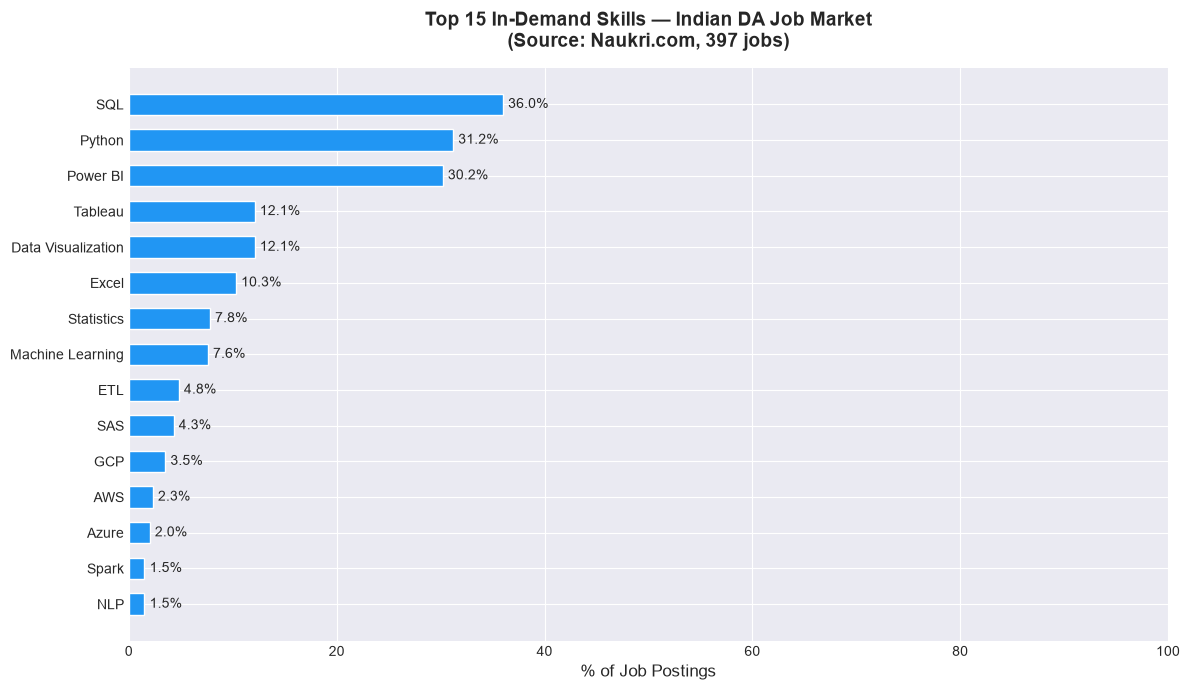

Chart saved.


In [9]:
# Chart 1 — Top 15 Skills by Demand
fig, ax = plt.subplots(figsize=(12, 7))

top_15 = skill_summary.head(15)

bars = ax.barh(
    top_15.index[::-1],
    top_15['demand_pct'][::-1],
    color='#2196F3',
    edgecolor='white',
    height=0.6
)

# Add percentage labels on bars
for bar, pct in zip(bars, top_15['demand_pct'][::-1]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{pct}%',
        va='center',
        fontsize=10
    )

ax.set_xlabel('% of Job Postings', fontsize=12)
ax.set_title('Top 15 In-Demand Skills — Indian DA Job Market\n(Source: Naukri.com, 397 jobs)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../data/top_skills_demand.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

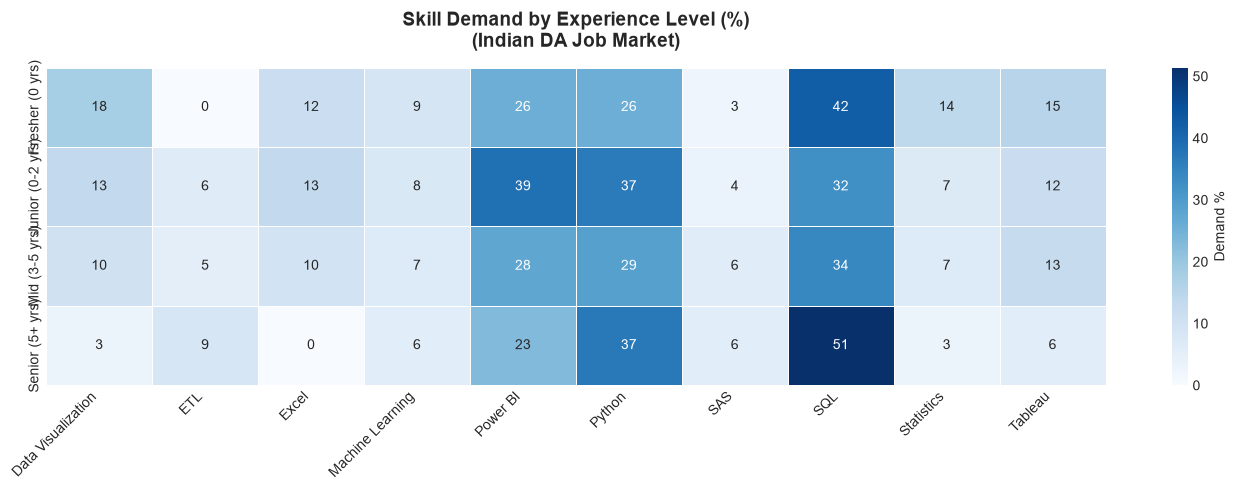

Chart saved.


In [10]:
# Chart 2 — Skill Demand by Experience Level

exp_levels = ['Fresher (0 yrs)', 'Junior (0-2 yrs)', 'Mid (3-5 yrs)', 'Senior (5+ yrs)']
top_10_skills = skill_summary.head(10).index.tolist()


exp_skill_data = []
for level in exp_levels:
    level_df = df[df['experience_level'] == level]
    if len(level_df) == 0:
        continue
    for skill in top_10_skills:
        pct = level_df[skill].mean() * 100
        exp_skill_data.append({
            'experience_level': level,
            'skill': skill,
            'demand_pct': round(pct, 1)
        })

exp_skill_df = pd.DataFrame(exp_skill_data)

# Pivot for heatmap
pivot = exp_skill_df.pivot(
    index='experience_level', 
    columns='skill', 
    values='demand_pct'
)
pivot = pivot.reindex(exp_levels)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Demand %'}
)
ax.set_title('Skill Demand by Experience Level (%)\n(Indian DA Job Market)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/skill_by_experience.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")